# Classification results

Set `DEBUG = True` in the setup cell to write figures under `Temp/Figures`. The source CSVs are read from the cloned repo results.


In [1]:
import os
import subprocess
import sys
from pathlib import Path

REPO_URL = "https://github.com/Daprosero/STF-KernelSHAP.git"
REPO_NAME = "STF-KernelSHAP"
PACKAGE_PATH = Path("src") / "stf_kernelshap"


def run_command(command, cwd=None):
    result = subprocess.run(
        command,
        cwd=cwd,
        text=True,
        capture_output=True,
    )
    if result.returncode != 0:
        message = [
            f"Command failed: {' '.join(map(str, command))}",
            f"Return code: {result.returncode}",
        ]
        if result.stdout:
            message.append(f"STDOUT:\n{result.stdout}")
        if result.stderr:
            message.append(f"STDERR:\n{result.stderr}")
        raise RuntimeError("\n".join(message))
    return result


def resolve_working_root():
    if Path("/kaggle/working").exists():
        return Path("/kaggle/working")
    if Path("/content").exists():
        return Path("/content")
    return Path.cwd().resolve()


def resolve_project_root():
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if (candidate / PACKAGE_PATH).exists():
            return candidate

    working_root = resolve_working_root()
    clone_dir = working_root / REPO_NAME

    if (clone_dir / PACKAGE_PATH).exists():
        return clone_dir.resolve()

    if clone_dir.exists() and (clone_dir / ".git").exists():
        run_command(["git", "-C", str(clone_dir), "pull", "--ff-only"])
        if (clone_dir / PACKAGE_PATH).exists():
            return clone_dir.resolve()

    if clone_dir.exists() and not (clone_dir / PACKAGE_PATH).exists():
        clone_dir = working_root / f"{REPO_NAME}_repo"

    if not clone_dir.exists():
        run_command(["git", "clone", "--depth", "1", REPO_URL, str(clone_dir)])

    if not (clone_dir / PACKAGE_PATH).exists():
        raise FileNotFoundError(
            f"El repositorio clonado no contiene {PACKAGE_PATH}: {clone_dir}"
        )

    return clone_dir.resolve()


def install_project_requirements(project_root):
    requirements_path = project_root / "requirements.txt"
    if not requirements_path.exists():
        raise FileNotFoundError(f"No existe requirements.txt en {project_root}")
    run_command([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "-r",
        str(requirements_path),
    ])


PROJECT_ROOT = resolve_project_root()
os.chdir(PROJECT_ROOT)

RUNNING_IN_COLAB = "COLAB_RELEASE_TAG" in os.environ or Path("/content").exists()
RUNNING_IN_KAGGLE = "KAGGLE_KERNEL_RUN_TYPE" in os.environ or Path("/kaggle").exists()
INSTALL_REQUIREMENTS = RUNNING_IN_COLAB or RUNNING_IN_KAGGLE

if INSTALL_REQUIREMENTS:
    install_project_requirements(PROJECT_ROOT)

SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

print("PROJECT_ROOT:", PROJECT_ROOT)
print("INSTALL_REQUIREMENTS:", INSTALL_REQUIREMENTS)


PROJECT_ROOT: /Users/diego/Documents/STF-KernelSHAP
INSTALL_REQUIREMENTS: False


In [2]:
from stf_kernelshap.notebook_setup import setup_notebook_environment

DEBUG = True
paths = setup_notebook_environment(debug=DEBUG)

DATA_DIR = paths.data_dir
MODELS_DIR = paths.models_dir
REPO_MODELS_DIR = paths.repo_models_dir
REPO_RESULTS_DIR = paths.repo_results_dir
REPO_FIGURES_DIR = paths.repo_figures_dir
OUTPUT_MODELS_DIR = paths.output_models_dir
RESULTS_DIR = paths.results_dir
FIGURES_DIR = paths.figures_dir


Repository root: /Users/diego/Documents/STF-KernelSHAP
Dataset root: /Users/diego/Documents/STF-KernelSHAP/MI_TDAH_Dataset
Debug mode: True
Results dir: /Users/diego/Documents/STF-KernelSHAP/Temp/Results
Figures dir: /Users/diego/Documents/STF-KernelSHAP/Temp/Figures
Output models dir: /Users/diego/Documents/STF-KernelSHAP/Temp/Models


In [3]:
from stf_kernelshap.reporting.classification_results import (
    plot_mi_window_figure,
    plot_tdah_bar_figure,
    summarize_mi_global,
    summarize_mi_subject_level,
    summarize_tdah_global,
)


In [4]:
mi_csv_path = REPO_RESULTS_DIR / "MI_results.csv"
tdah_csv_path = REPO_RESULTS_DIR / "TDAH_results.csv"

mi_global_summary = summarize_mi_global(mi_csv_path)
mi_subject_summary = summarize_mi_subject_level(mi_csv_path)
tdah_summary, tdah_fold_metrics = summarize_tdah_global(tdah_csv_path)


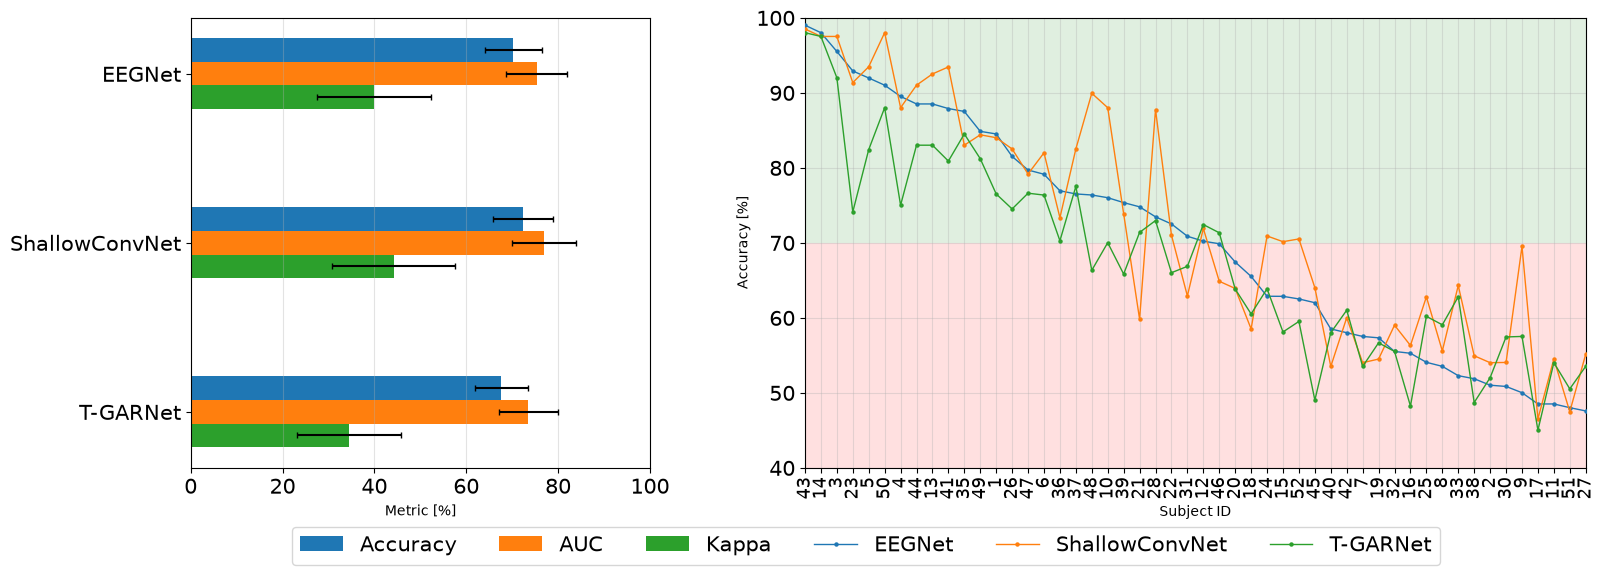

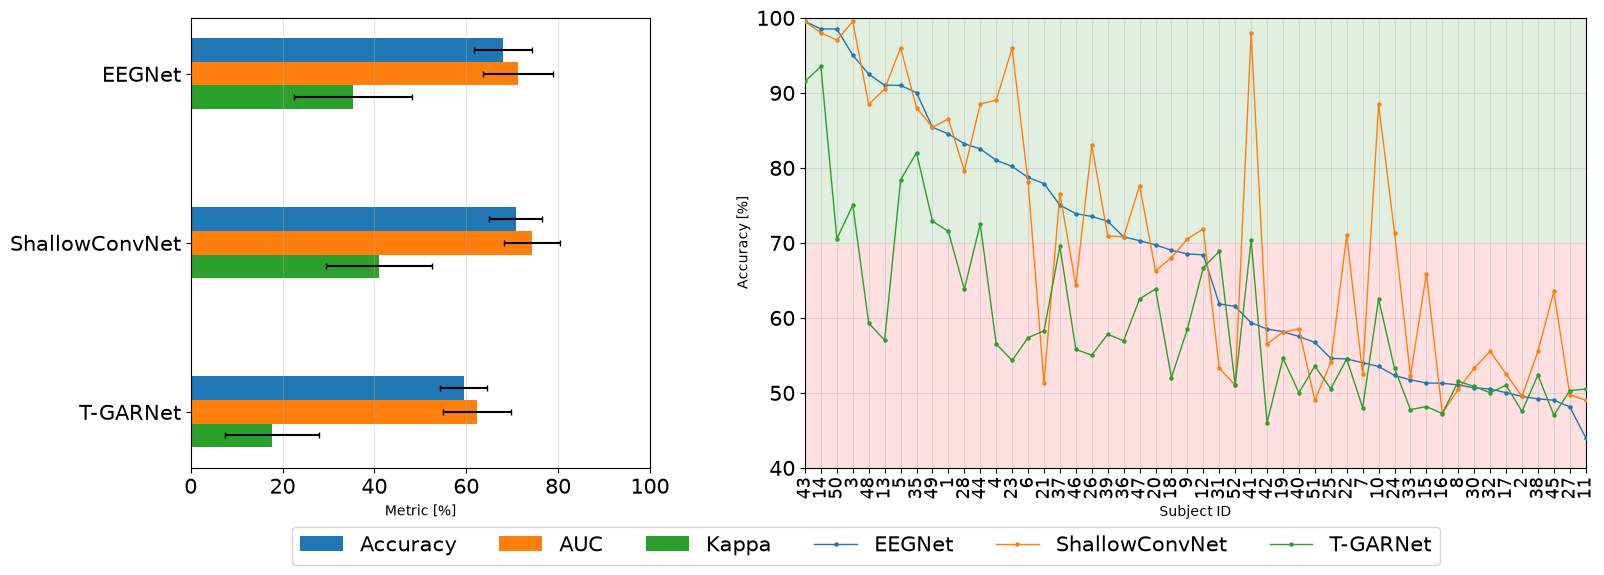

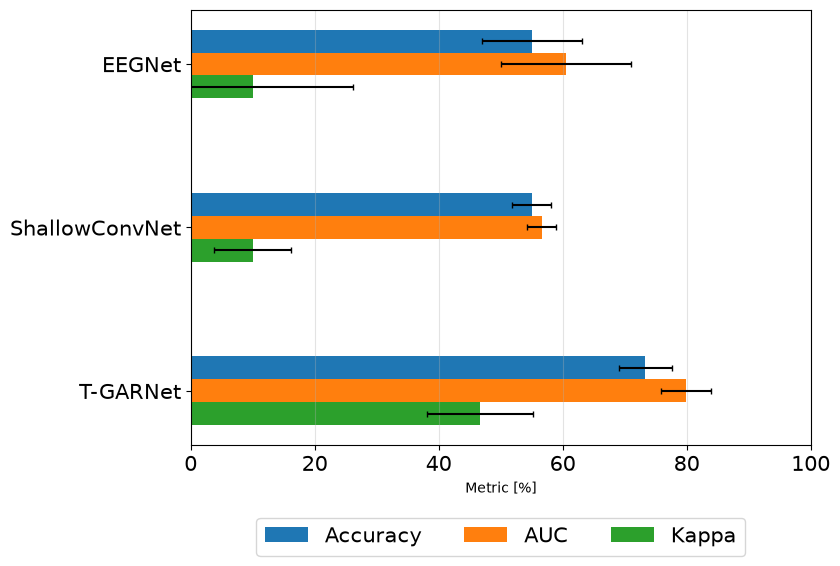

In [5]:
plot_mi_window_figure(
    window_name="2.5-5",
    mi_global_summary=mi_global_summary,
    mi_subject_summary=mi_subject_summary,
    save_path=str(FIGURES_DIR / "Cl_MI_2_5_5.pdf"),
)

plot_mi_window_figure(
    window_name="0-7",
    mi_global_summary=mi_global_summary,
    mi_subject_summary=mi_subject_summary,
    save_path=str(FIGURES_DIR / "Cl_MI_0_7.pdf"),
)

plot_tdah_bar_figure(
    tdah_summary=tdah_summary,
    save_path=str(FIGURES_DIR / "Cl_TDAH.pdf"),
)
